# 13 Test-Noisy Evaluation and Cross-Model Comparison

This notebook evaluates all tuned VAD models on the **test-noisy** split and compares their performance.

Models are loaded from final tuned config files under `artifacts/`:
- clean baseline MLP
- noisy baseline MLP
- noisy offline MLP
- lazy noisy MLP
- lazy CRNN

Each model is evaluated using its tuned threshold from its corresponding final config.

### Step 1: Import libraries
This step imports required libraries for model loading, inference, metrics, and plotting.

In [1]:
import json
import sys
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


### Step 2: Resolve project paths and runtime config
This step resolves project paths, imports model/data modules, and sets shared runtime settings.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists() and (candidate / 'data' / 'generated').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from current working directory.')

ROOT = find_project_root(Path.cwd())
SRC_05 = ROOT / 'src' / '05_baseline_training'
SRC_07 = ROOT / 'src' / '07_lazy_feature_mlp'
SRC_08 = ROOT / 'src' / '08_crnn'

for p in (SRC_05, SRC_07, SRC_08):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from baseline_mlp import BaselineMLP
from offline_dataset import OfflineFrameDataset
from lazy_frame_dataset import VADLazyFrameDataset
from lazy_dataset import VADLazySequenceDataset
from crnn import CRNNVAD

DATA_ROOT = ROOT / 'data' / 'generated'
ARTIFACTS_DIR = ROOT / 'artifacts'

MANIFEST_TYPE = 'noisy'
NORM_STATS_PATH = DATA_ROOT / 'train' / 'features' / 'noisy_norm_stats.npz'

FRAME_BATCH_SIZE = 2048
SEQ_BATCH_SIZE = 8
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Optional quick check: set to float in (0,1] to evaluate subset only
TEST_SUBSET_FRACTION = None

print('Project root      :', ROOT)
print('Data root         :', DATA_ROOT)
print('Artifacts dir     :', ARTIFACTS_DIR)
print('Norm stats path   :', NORM_STATS_PATH)
print('Device            :', DEVICE)

Project root      : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Data root         : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
Artifacts dir     : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts
Norm stats path   : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/train/features/noisy_norm_stats.npz
Device            : cuda


### Step 3: Define helper functions
This step defines config loading, model loading, dataloader builders, and evaluation helpers.

In [3]:
CONFIG_FILES = {
    'clean_baseline_mlp': ARTIFACTS_DIR / 'final_tuned_config_clean_baseline_mlp.json',
    'noisy_baseline_mlp': ARTIFACTS_DIR / 'final_tuned_config_noisy_baseline_mlp.json',
    'noisy_mlp': ARTIFACTS_DIR / 'final_tuned_config_noisy_mlp.json',
    'lazy_noisy_mlp': ARTIFACTS_DIR / 'final_tuned_config_lazy_noisy_mlp.json',
    'lazy_crnn': ARTIFACTS_DIR / 'final_tuned_config_lazy_crnn.json',
}


def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def _infer_mlp_shape_from_state(state_dict):
    linear_layers = []
    for k, v in state_dict.items():
        if not (k.startswith('backbone.') and k.endswith('.weight')):
            continue
        if not hasattr(v, 'shape') or len(v.shape) != 2:
            continue
        parts = k.split('.')
        if len(parts) < 3 or not parts[1].isdigit():
            continue
        idx = int(parts[1])
        out_dim, in_dim = int(v.shape[0]), int(v.shape[1])
        linear_layers.append((idx, in_dim, out_dim))

    if not linear_layers:
        raise RuntimeError('Could not infer MLP backbone layers from state_dict.')

    linear_layers.sort(key=lambda t: t[0])
    input_dim = linear_layers[0][1]
    hidden_dims = tuple(layer[2] for layer in linear_layers)
    dropout = 0.1 if len(linear_layers) >= 2 and (linear_layers[1][0] - linear_layers[0][0] == 3) else 0.0
    return input_dim, hidden_dims, dropout


def parse_conv_channels(raw) -> Tuple[int, int]:
    vals = [int(v.strip()) for v in str(raw).split(',') if v.strip()]
    if len(vals) != 2:
        raise ValueError('conv_channels must contain exactly two integers, e.g. "64,128"')
    return vals[0], vals[1]


def load_json(path: Path) -> Dict:
    return json.loads(path.read_text(encoding='utf-8'))


def load_tuned_configs(config_files: Dict[str, Path]) -> Dict[str, Dict]:
    loaded = {}
    missing = []
    for name, path in config_files.items():
        if not path.exists():
            missing.append((name, path))
            continue
        loaded[name] = load_json(path)

    if missing:
        print('Missing config files:')
        for name, path in missing:
            print(' -', name, '->', path)

    if not loaded:
        raise FileNotFoundError('No final tuned config files were found.')

    return loaded


def build_test_loaders():
    pin = torch.cuda.is_available()

    offline_dataset = OfflineFrameDataset(
        generated_dir=DATA_ROOT / 'test',
        split='test',
        manifest_type='noisy',
    )
    offline_loader = DataLoader(
        offline_dataset,
        batch_size=FRAME_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        drop_last=False,
    )

    lazy_frame_dataset = VADLazyFrameDataset(
        generated_dir=DATA_ROOT,
        split='test',
        manifest_type='noisy',
        norm_stats_path=NORM_STATS_PATH if NORM_STATS_PATH.exists() else None,
        subset_fraction=TEST_SUBSET_FRACTION,
        context_left=5,
        context_right=5,
    )
    lazy_frame_loader = DataLoader(
        lazy_frame_dataset,
        batch_size=FRAME_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        drop_last=False,
    )

    def seq_collate(batch):
        lengths = [int(item['num_frames']) for item in batch]
        max_len = max(lengths)
        feat_dim = int(batch[0]['x'].shape[-1])

        x_pad = torch.zeros((len(batch), max_len, feat_dim), dtype=torch.float32)
        y_pad = torch.zeros((len(batch), max_len), dtype=torch.float32)
        mask = torch.zeros((len(batch), max_len), dtype=torch.bool)

        for i, item in enumerate(batch):
            t = int(item['num_frames'])
            x_pad[i, :t] = item['x']
            y_pad[i, :t] = item['y']
            mask[i, :t] = True

        return {'x': x_pad, 'y': y_pad, 'mask': mask}

    lazy_seq_dataset = VADLazySequenceDataset(
        generated_dir=DATA_ROOT,
        split='test',
        manifest_type='noisy',
        norm_stats_path=NORM_STATS_PATH if NORM_STATS_PATH.exists() else None,
        subset_fraction=TEST_SUBSET_FRACTION,
    )
    lazy_seq_loader = DataLoader(
        lazy_seq_dataset,
        batch_size=SEQ_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        drop_last=False,
        collate_fn=seq_collate,
    )

    return offline_loader, lazy_frame_loader, lazy_seq_loader


def load_mlp_checkpoint(checkpoint_path: Path, device: torch.device) -> BaselineMLP:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    input_dim, hidden_dims, dropout = _infer_mlp_shape_from_state(state)
    model = BaselineMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def load_crnn_checkpoint(checkpoint_path: Path, device: torch.device) -> CRNNVAD:
    run_dir = checkpoint_path.parent
    args_path = run_dir / 'train_args.json'

    if args_path.exists():
        args = load_json(args_path)
        conv_channels = parse_conv_channels(args.get('conv_channels', '64,128'))
        conv_kernel_size = int(args.get('conv_kernel_size', 5))
        rnn_hidden_size = int(args.get('rnn_hidden_size', 128))
        rnn_layers = int(args.get('rnn_layers', 1))
        rnn_bidirectional = bool(int(args.get('rnn_bidirectional', 1)))
        dropout = float(args.get('dropout', 0.1))
    else:
        conv_channels = (64, 128)
        conv_kernel_size = 5
        rnn_hidden_size = 128
        rnn_layers = 1
        rnn_bidirectional = True
        dropout = 0.1

    model = CRNNVAD(
        input_dim=121,
        conv_channels=conv_channels,
        conv_kernel_size=conv_kernel_size,
        rnn_hidden_size=rnn_hidden_size,
        rnn_layers=rnn_layers,
        rnn_bidirectional=rnn_bidirectional,
        dropout=dropout,
    )

    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def metrics_from_pred(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))
    far = fp / max(1, fp + tn)
    miss = fn / max(1, fn + tp)

    return {
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'far': float(far),
        'miss_rate': float(miss),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


@torch.no_grad()
def eval_frame_model(model: torch.nn.Module, loader: DataLoader, threshold: float, device: torch.device):
    probs_all = []
    labels_all = []

    for batch in loader:
        if isinstance(batch, dict):
            x = batch['x'].to(device, non_blocking=True)
            y = batch['y'].detach().cpu().numpy().astype(np.int64)
        else:
            x, y_t = batch
            x = x.to(device, non_blocking=True)
            y = y_t.detach().cpu().numpy().astype(np.int64)

        logits = model(x).squeeze(-1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()

        probs_all.append(probs)
        labels_all.append(y)

    probs_np = np.concatenate(probs_all)
    labels_np = np.concatenate(labels_all)
    preds_np = (probs_np >= threshold).astype(np.int64)

    metrics = metrics_from_pred(labels_np, preds_np)
    return metrics, labels_np, preds_np, probs_np


@torch.no_grad()
def eval_seq_crnn(model: CRNNVAD, loader: DataLoader, threshold: float, device: torch.device):
    probs_all = []
    labels_all = []

    for batch in loader:
        x = batch['x'].to(device, non_blocking=True)
        y = batch['y'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)

        logits = model(x)
        probs = torch.sigmoid(logits)

        probs_valid = probs[mask].detach().cpu().numpy()
        labels_valid = y[mask].detach().cpu().numpy().astype(np.int64)

        probs_all.append(probs_valid)
        labels_all.append(labels_valid)

    probs_np = np.concatenate(probs_all)
    labels_np = np.concatenate(labels_all)
    preds_np = (probs_np >= threshold).astype(np.int64)

    metrics = metrics_from_pred(labels_np, preds_np)
    return metrics, labels_np, preds_np, probs_np

### Step 4: Load final tuned configs
This step reads each final tuned config and confirms checkpoint paths and tuned thresholds.

In [4]:
tuned_configs = load_tuned_configs(CONFIG_FILES)

print('Loaded tuned configs:', len(tuned_configs))
for name, cfg in tuned_configs.items():
    print(f"- {name:20s} threshold={cfg.get('threshold')} checkpoint={cfg.get('checkpoint')}")

Loaded tuned configs: 5
- clean_baseline_mlp   threshold=0.3 checkpoint=/home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/checkpoints/baseline_mlp_lr0.0003_wd0_dr0.1_seed42.pt
- noisy_baseline_mlp   threshold=0.05 checkpoint=/home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/checkpoints/baseline_mlp_lr0.001_wd1e-5_dr0.1_seed42.pt
- noisy_mlp            threshold=0.44999999999999996 checkpoint=/home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/checkpoints/noisy_mlp_lr0.001_wd1e-5_dr0.0_seed42.pt
- lazy_noisy_mlp       threshold=0.44999999999999996 checkpoint=/home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/lazy_checkpoints/lazy_mlp_lr0.001_wd1e-5_dr0.0_seed42/best_model.pt
- lazy_crnn            threshold=0.65 checkpoint=/home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/lazy_crnn_checkpoints/lazy_crnn_lr0.001_wd1e-5_dr0.1_seed42/best_model.pt


### Step 5: Build test-noisy dataloaders
This step builds test-noisy dataloaders for offline MLP, lazy MLP, and lazy CRNN evaluation paths.

In [5]:
offline_loader, lazy_frame_loader, lazy_seq_loader = build_test_loaders()

print('Offline frames dataset size :', len(offline_loader.dataset))
print('Lazy frame dataset size     :', len(lazy_frame_loader.dataset))
print('Lazy sequence dataset size  :', len(lazy_seq_loader.dataset))

Loaded 500 examples from test noisy manifest
Frame dataset: 1086683 total frames from 500 sequences
Loaded 500 examples from test noisy manifest
Offline frames dataset size : 1086683
Lazy frame dataset size     : 1086683
Lazy sequence dataset size  : 500


### Step 6: Evaluate each tuned model on test-noisy
This step runs inference using each model's tuned threshold and stores results for comparison.

In [6]:
results = []
detailed_outputs = {}

for model_name, cfg in tuned_configs.items():
    ckpt = Path(cfg['checkpoint'])
    threshold = float(cfg['threshold'])

    if not ckpt.exists():
        print(f"[SKIP] {model_name}: checkpoint not found -> {ckpt}")
        continue

    print(f"\nEvaluating {model_name} ...")

    if model_name == 'lazy_crnn':
        model = load_crnn_checkpoint(ckpt, DEVICE)
        metrics, y_true, y_pred, y_prob = eval_seq_crnn(model, lazy_seq_loader, threshold, DEVICE)
        eval_path = 'lazy_sequence_crnn'
    elif model_name == 'lazy_noisy_mlp':
        model = load_mlp_checkpoint(ckpt, DEVICE)
        metrics, y_true, y_pred, y_prob = eval_frame_model(model, lazy_frame_loader, threshold, DEVICE)
        eval_path = 'lazy_frame_mlp'
    else:
        model = load_mlp_checkpoint(ckpt, DEVICE)
        metrics, y_true, y_pred, y_prob = eval_frame_model(model, offline_loader, threshold, DEVICE)
        eval_path = 'offline_frame_mlp'

    row = {
        'model': model_name,
        'threshold': threshold,
        'eval_path': eval_path,
        **metrics,
    }
    results.append(row)

    detailed_outputs[model_name] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

    print(
        f"  F1={metrics['f1']:.6f}, Acc={metrics['accuracy']:.6f}, "
        f"P={metrics['precision']:.6f}, R={metrics['recall']:.6f}, "
        f"FAR={metrics['far']:.6f}, Miss={metrics['miss_rate']:.6f}"
    )

if not results:
    raise RuntimeError('No model was evaluated successfully.')

ranked = sorted(results, key=lambda x: x['f1'], reverse=True)
best = ranked[0]

print('\nBest model on test-noisy:', best['model'])
print('Best F1:', f"{best['f1']:.6f}")


Evaluating clean_baseline_mlp ...
  F1=0.844760, Acc=0.750915, P=0.742195, R=0.980218, FAR=0.762799, Miss=0.019782

Evaluating noisy_baseline_mlp ...
  F1=0.845209, Acc=0.750891, P=0.740910, R=0.983683, FAR=0.770644, Miss=0.016317

Evaluating noisy_mlp ...
  F1=0.881547, Acc=0.830852, P=0.854501, R=0.910362, FAR=0.347277, Miss=0.089638

Evaluating lazy_noisy_mlp ...
  F1=0.874199, Acc=0.816406, P=0.830596, R=0.922632, FAR=0.421576, Miss=0.077368

Evaluating lazy_crnn ...
  F1=0.917296, Acc=0.882877, P=0.896160, R=0.939453, FAR=0.243875, Miss=0.060547

Best model on test-noisy: lazy_crnn
Best F1: 0.917296


### Step 7: Print model comparison leaderboard
This step prints a compact ranked leaderboard across all evaluated models.

In [7]:
print('Test-Noisy Leaderboard (sorted by F1)')
print('-' * 146)
print(f"{'rank':>4s}  {'model':<22s}  {'path':<18s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}  {'far':>9s}  {'miss':>9s}")
print('-' * 146)

for i, r in enumerate(ranked, start=1):
    print(
        f"{i:>4d}  {r['model']:<22.22s}  {r['eval_path']:<18.18s}  {r['threshold']:>5.2f}  "
        f"{r['f1']:>9.6f}  {r['accuracy']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}  "
        f"{r['far']:>9.6f}  {r['miss_rate']:>9.6f}"
    )

Test-Noisy Leaderboard (sorted by F1)
--------------------------------------------------------------------------------------------------------------------------------------------------
rank  model                   path                  thr         f1        acc       prec        rec        far       miss
--------------------------------------------------------------------------------------------------------------------------------------------------
   1  lazy_crnn               lazy_sequence_crnn   0.65   0.917296   0.882877   0.896160   0.939453   0.243875   0.060547
   2  noisy_mlp               offline_frame_mlp    0.45   0.881547   0.830852   0.854501   0.910362   0.347277   0.089638
   3  lazy_noisy_mlp          lazy_frame_mlp       0.45   0.874199   0.816406   0.830596   0.922632   0.421576   0.077368
   4  noisy_baseline_mlp      offline_frame_mlp    0.05   0.845209   0.750891   0.740910   0.983683   0.770644   0.016317
   5  clean_baseline_mlp      offline_frame_mlp    0.30   

**Output explanation**

On the noisy test set, the lazy CRNN achieved the best performance with an F1 score of 0.9173, outperforming all MLP-based models. It provides a strong balance between precision and recall while maintaining the lowest miss rate. Among MLPs, the noisy-trained MLP performed best, showing that training with noisy data improves robustness. Overall, the results indicate that sequence models like CRNN are more effective than frame-based MLPs for noise-robust voice activity detection.

### Step 8: Plot side-by-side metric comparison
This step visualizes F1, precision, recall, FAR, and miss rate across models.

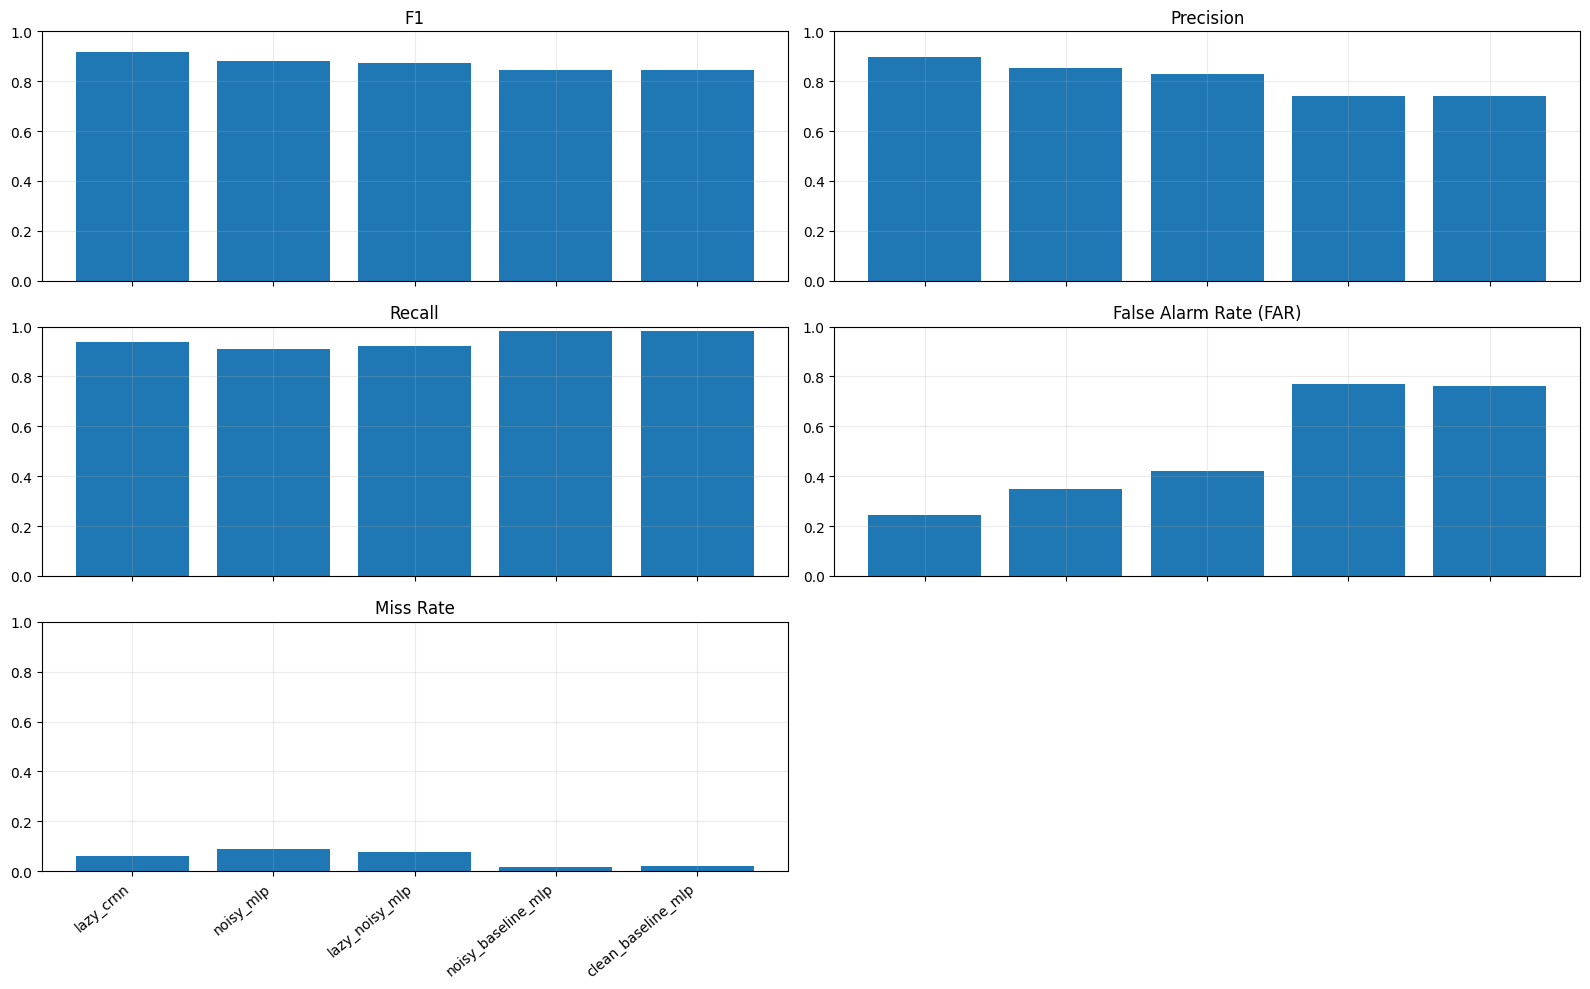

In [8]:
models = [r['model'] for r in ranked]
x = np.arange(len(ranked))

f1_vals = [r['f1'] for r in ranked]
prec_vals = [r['precision'] for r in ranked]
rec_vals = [r['recall'] for r in ranked]
far_vals = [r['far'] for r in ranked]
miss_vals = [r['miss_rate'] for r in ranked]

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()

axes[0].bar(x, f1_vals)
axes[0].set_title('F1')
axes[0].set_ylim(0, 1)

axes[1].bar(x, prec_vals)
axes[1].set_title('Precision')
axes[1].set_ylim(0, 1)

axes[2].bar(x, rec_vals)
axes[2].set_title('Recall')
axes[2].set_ylim(0, 1)

axes[3].bar(x, far_vals)
axes[3].set_title('False Alarm Rate (FAR)')
axes[3].set_ylim(0, 1)

axes[4].bar(x, miss_vals)
axes[4].set_title('Miss Rate')
axes[4].set_ylim(0, 1)

axes[5].axis('off')

for ax in axes[:5]:
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=40, ha='right')

plt.tight_layout()
plt.show()

**Output explanation**

The results show that the lazy CRNN achieves the highest F1 and precision while maintaining strong recall and the lowest false alarm rate, making it the best overall model. In contrast, MLP models have slightly lower F1 scores and much higher false alarm rates, even though their recall is high. This indicates that MLPs tend to over-predict speech, while the CRNN provides a better balance between detecting speech and avoiding false positives.

### Step 9: Save test-noisy comparison artifacts
This step saves the leaderboard JSON and per-model prediction arrays for reproducibility.

In [9]:
out_dir = ARTIFACTS_DIR / 'eval_outputs_test_noisy_model_comparison'
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / 'test_noisy_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(ranked, f, indent=2)

for model_name, payload in detailed_outputs.items():
    np.save(out_dir / f'{model_name}_y_true.npy', payload['y_true'])
    np.save(out_dir / f'{model_name}_y_pred.npy', payload['y_pred'])
    np.save(out_dir / f'{model_name}_y_prob.npy', payload['y_prob'])

summary_path = out_dir / 'best_model_on_test_noisy.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(best, f, indent=2)

print('Saved leaderboard to :', out_dir / 'test_noisy_leaderboard.json')
print('Saved best summary to:', summary_path)
print('Saved prediction arrays under:', out_dir)

Saved leaderboard to : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_test_noisy_model_comparison/test_noisy_leaderboard.json
Saved best summary to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_test_noisy_model_comparison/best_model_on_test_noisy.json
Saved prediction arrays under: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_test_noisy_model_comparison


### Step 10: Build frame-level noise metadata for breakdown analysis
This step builds aligned frame-level metadata (SNR bucket and noise type) so each model's predictions can be analyzed by condition.

In [10]:
import numpy as np
from collections import defaultdict

SNR_BUCKETS = np.array([-5.0, 0.0, 5.0, 10.0, 20.0], dtype=np.float32)

def nearest_snr_bucket(snr_value: float) -> float:
    idx = int(np.argmin(np.abs(SNR_BUCKETS - float(snr_value))))
    return float(SNR_BUCKETS[idx])

def load_test_noise_meta():
    manifest_path = DATA_ROOT / 'test' / 'manifests' / 'test_noisy_manifest.jsonl'
    rows = []
    with open(manifest_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    meta_by_exid = {}
    for row in rows:
        noise = row.get('noise', {}) or {}
        noise_type = str(noise.get('noise_type', 'unknown'))
        snr_actual = noise.get('snr_db_actual', noise.get('snr_db_target', 0.0))
        snr_bucket = nearest_snr_bucket(float(snr_actual))
        meta_by_exid[row['ex_id']] = {
            'noise_type': noise_type,
            'snr_actual': float(snr_actual),
            'snr_bucket': snr_bucket,
        }
    return meta_by_exid

def build_offline_frame_meta_array(offline_dataset, meta_by_exid):
    snr_buckets = []
    noise_types = []
    for row in offline_dataset.rows:
        meta = meta_by_exid.get(row.ex_id, {'snr_bucket': 0.0, 'noise_type': 'unknown'})
        n = int(row.num_frames)
        snr_buckets.extend([meta['snr_bucket']] * n)
        noise_types.extend([meta['noise_type']] * n)
    return np.asarray(snr_buckets, dtype=np.float32), np.asarray(noise_types, dtype=object)

def build_lazy_frame_meta_array(lazy_frame_dataset, meta_by_exid):
    snr_buckets = []
    noise_types = []
    for seq_idx, frame_idx, ex_id in lazy_frame_dataset.frame_mapping:
        meta = meta_by_exid.get(ex_id, {'snr_bucket': 0.0, 'noise_type': 'unknown'})
        snr_buckets.append(meta['snr_bucket'])
        noise_types.append(meta['noise_type'])
    return np.asarray(snr_buckets, dtype=np.float32), np.asarray(noise_types, dtype=object)

def build_lazy_seq_meta_array(lazy_seq_dataset, meta_by_exid):
    snr_buckets = []
    noise_types = []
    base_dir = DATA_ROOT / 'test'
    for row in lazy_seq_dataset.manifest_rows:
        ex_id = row['ex_id']
        labels_path = base_dir / row['labels_path']
        num_frames = int(np.load(labels_path, mmap_mode='r').shape[0])
        meta = meta_by_exid.get(ex_id, {'snr_bucket': 0.0, 'noise_type': 'unknown'})
        snr_buckets.extend([meta['snr_bucket']] * num_frames)
        noise_types.extend([meta['noise_type']] * num_frames)
    return np.asarray(snr_buckets, dtype=np.float32), np.asarray(noise_types, dtype=object)

meta_by_exid = load_test_noise_meta()
offline_snr_meta, offline_noise_meta = build_offline_frame_meta_array(offline_loader.dataset, meta_by_exid)
lazy_frame_snr_meta, lazy_frame_noise_meta = build_lazy_frame_meta_array(lazy_frame_loader.dataset, meta_by_exid)
lazy_seq_snr_meta, lazy_seq_noise_meta = build_lazy_seq_meta_array(lazy_seq_loader.dataset, meta_by_exid)

print('Metadata arrays ready:')
print(' offline frames:', len(offline_snr_meta))
print(' lazy frame   :', len(lazy_frame_snr_meta))
print(' lazy seq     :', len(lazy_seq_snr_meta))

Metadata arrays ready:
 offline frames: 1086683
 lazy frame   : 1086683
 lazy seq     : 1086683


### Step 11: Compute F1, FAR, and MR by SNR bucket and noise type
This step computes per-model condition-wise metrics and prints compact tables for comparison.

In [11]:
def compute_group_metrics(y_true: np.ndarray, y_pred: np.ndarray, group_values: np.ndarray):
    out = []
    unique_vals = sorted(list(set(group_values.tolist())))
    for g in unique_vals:
        idx = (group_values == g)
        n = int(np.sum(idx))
        if n == 0:
            continue
        m = metrics_from_pred(y_true[idx], y_pred[idx])
        m['group'] = g
        m['support'] = n
        out.append(m)
    return out

def print_group_table(title: str, rows: List[Dict], group_fmt=str):
    print('\n' + title)
    print('-' * 88)
    print(f"{'group':>12s}  {'support':>10s}  {'f1':>9s}  {'far':>9s}  {'mr':>9s}  {'prec':>9s}  {'rec':>9s}")
    print('-' * 88)
    for r in rows:
        g = group_fmt(r['group'])
        print(
            f"{g:>12s}  {r['support']:>10d}  {r['f1']:>9.6f}  {r['far']:>9.6f}  {r['miss_rate']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}"
        )

def get_model_meta_arrays(model_row: Dict):
    eval_path = model_row['eval_path']
    if eval_path == 'offline_frame_mlp':
        return offline_snr_meta, offline_noise_meta
    if eval_path == 'lazy_frame_mlp':
        return lazy_frame_snr_meta, lazy_frame_noise_meta
    if eval_path == 'lazy_sequence_crnn':
        return lazy_seq_snr_meta, lazy_seq_noise_meta
    raise ValueError(f"Unknown eval_path: {eval_path}")

snr_breakdown = {}
noise_breakdown = {}

for r in ranked:
    model_name = r['model']
    y_true = detailed_outputs[model_name]['y_true']
    y_pred = detailed_outputs[model_name]['y_pred']

    snr_meta, noise_meta = get_model_meta_arrays(r)
    if len(y_true) != len(snr_meta):
        raise RuntimeError(f"Length mismatch for {model_name}: y_true={len(y_true)} snr_meta={len(snr_meta)}")

    snr_rows = compute_group_metrics(y_true, y_pred, snr_meta)
    noise_rows = compute_group_metrics(y_true, y_pred, noise_meta)

    snr_rows = sorted(snr_rows, key=lambda x: float(x['group']))
    noise_rows = sorted(noise_rows, key=lambda x: str(x['group']))

    snr_breakdown[model_name] = snr_rows
    noise_breakdown[model_name] = noise_rows

    print_group_table(f"{model_name} | By SNR bucket", snr_rows, group_fmt=lambda g: f"{float(g):.0f}")
    print_group_table(f"{model_name} | By noise type", noise_rows, group_fmt=lambda g: str(g))


lazy_crnn | By SNR bucket
----------------------------------------------------------------------------------------
       group     support         f1        far         mr       prec        rec
----------------------------------------------------------------------------------------
          -5      239178   0.885924   0.383216   0.070010   0.845845   0.929990
           0      205028   0.904404   0.300737   0.065080   0.875817   0.934920
           5      224343   0.921803   0.250433   0.050495   0.895673   0.949505
          10      222779   0.936763   0.162581   0.054372   0.928064   0.945628
          20      195355   0.944501   0.103508   0.062768   0.951885   0.937232

lazy_crnn | By noise type
----------------------------------------------------------------------------------------
       group     support         f1        far         mr       prec        rec
----------------------------------------------------------------------------------------
      babble      206343   0.9

### Step 12: Visualize SNR/noise-type breakdown
This step plots F1, FAR, and MR per SNR bucket and per noise type for each model.

In [12]:
# Save SNR/noise-type breakdown artifacts
breakdown_dir = ARTIFACTS_DIR / 'eval_outputs_test_noisy_model_comparison'
breakdown_dir.mkdir(parents=True, exist_ok=True)

with open(breakdown_dir / 'snr_breakdown.json', 'w', encoding='utf-8') as f:
    json.dump(snr_breakdown, f, indent=2)

with open(breakdown_dir / 'noise_type_breakdown.json', 'w', encoding='utf-8') as f:
    json.dump(noise_breakdown, f, indent=2)

print('Saved:', breakdown_dir / 'snr_breakdown.json')
print('Saved:', breakdown_dir / 'noise_type_breakdown.json')

Saved: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_test_noisy_model_comparison/snr_breakdown.json
Saved: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_test_noisy_model_comparison/noise_type_breakdown.json


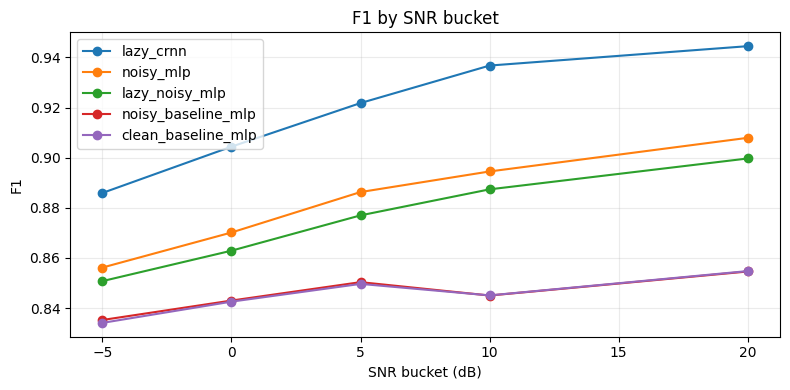

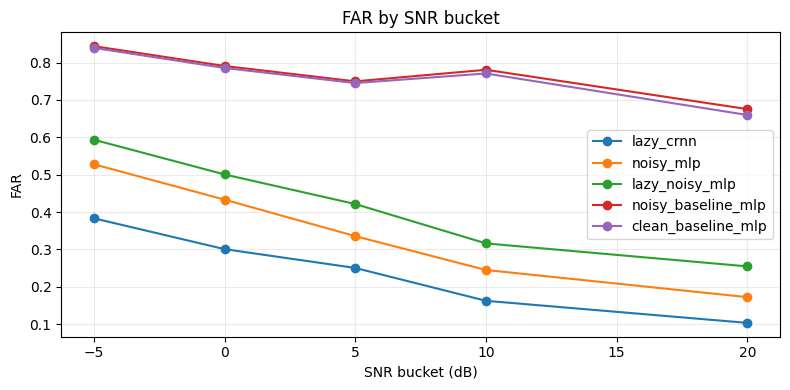

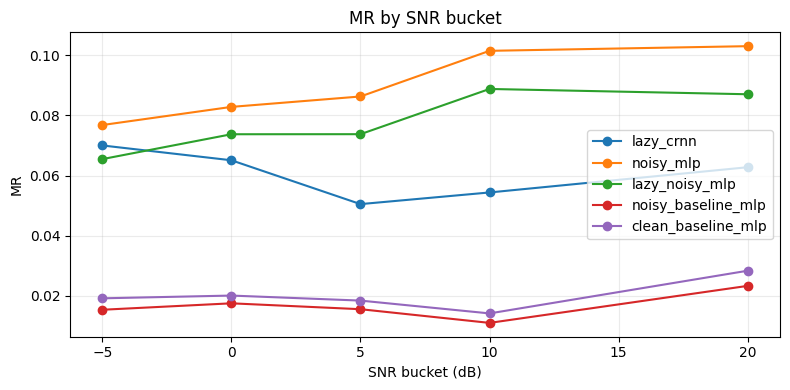

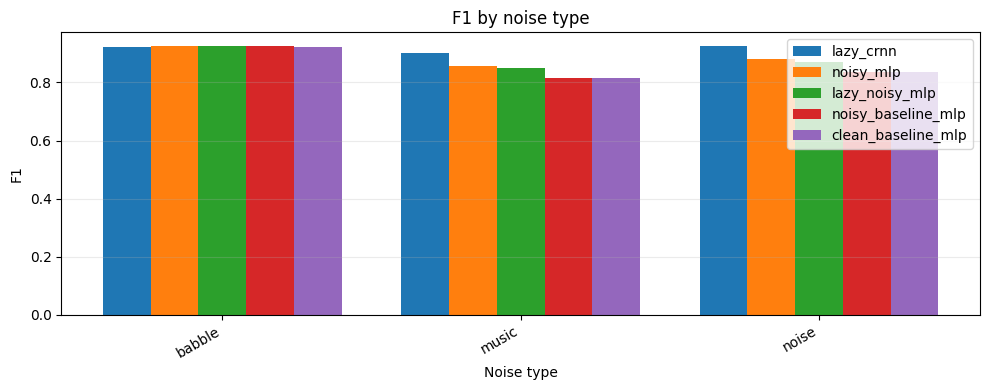

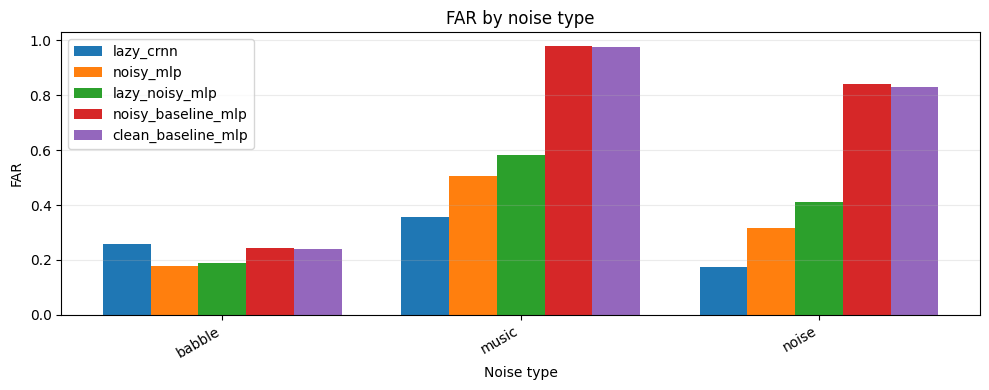

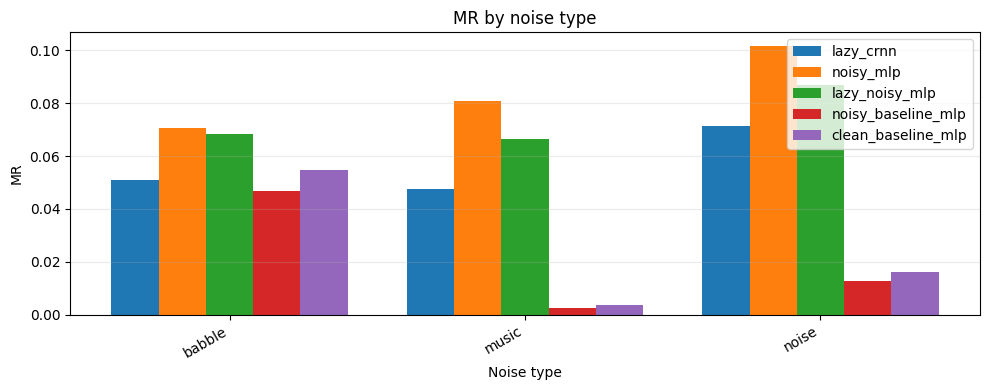

In [13]:
def rows_to_metric_dict(rows, metric):
    d = {}
    for r in rows:
        d[r['group']] = r[metric]
    return d

# Plot by SNR bucket
snr_keys = [float(v) for v in SNR_BUCKETS.tolist()]
metric_names = [('f1', 'F1'), ('far', 'FAR'), ('miss_rate', 'MR')]

for metric_key, metric_title in metric_names:
    plt.figure(figsize=(8, 4))
    for r in ranked:
        name = r['model']
        d = rows_to_metric_dict(snr_breakdown[name], metric_key)
        y = [d.get(k, np.nan) for k in snr_keys]
        plt.plot(snr_keys, y, marker='o', label=name)
    plt.title(f'{metric_title} by SNR bucket')
    plt.xlabel('SNR bucket (dB)')
    plt.ylabel(metric_title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot by noise type
all_noise_types = sorted({row['group'] for rows in noise_breakdown.values() for row in rows})

for metric_key, metric_title in metric_names:
    plt.figure(figsize=(10, 4))
    x = np.arange(len(all_noise_types))
    width = 0.8 / max(1, len(ranked))

    for i, r in enumerate(ranked):
        name = r['model']
        d = rows_to_metric_dict(noise_breakdown[name], metric_key)
        y = [d.get(k, np.nan) for k in all_noise_types]
        plt.bar(x + i * width, y, width=width, label=name)

    plt.title(f'{metric_title} by noise type')
    plt.xlabel('Noise type')
    plt.ylabel(metric_title)
    plt.xticks(x + width * (len(ranked) - 1) / 2, all_noise_types, rotation=30, ha='right')
    plt.grid(axis='y', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### **Output explanation**

The following results analyze model performance across different **noise levels (SNR)** and **noise types**, using **F1 score**, **False Alarm Rate (FAR)**, and **Miss Rate (MR)**.

---

#### **Performance Across SNR Levels**

- As **SNR increases (cleaner audio)** → all models improve:
  - Higher **F1**
  - Lower **FAR**
- However, clear differences exist between models:

**Key Observation**
- **lazy CRNN consistently achieves the highest F1 across all SNR levels**
- Even at **-5 dB (very noisy)**, CRNN remains strong

**Interpretation:**
- CRNN is more robust under extreme noise conditions
- MLP models degrade more in low SNR environments

---

#### **False Alarm Rate (FAR) Analysis**

- **CRNN has significantly lower FAR across all SNR levels**
- **Baseline MLPs have very high FAR (~0.7–0.8)**

**Key Insight**
- MLP models tend to **over-predict speech**
- CRNN maintains a better balance between detecting speech and avoiding false positives

---

#### **Miss Rate (MR) Tradeoff**

- **MLP models → lower Miss Rate**
  - Rarely miss speech segments
- BUT:
  - This comes with **very high False Alarm Rate**

**Tradeoff Summary**
- MLP:  
  - Low MR (good recall)  
  - High FAR (poor precision)
- CRNN:  
  - Balanced MR and FAR  
  - Best overall F1

**Conclusion:**
- CRNN achieves better overall performance by balancing detection and false alarms

---

#### **Performance Across Noise Types**

**Noise Difficulty Ranking**
- **Easiest:** Babble  
- **Hardest:** Music  
- **Medium:** Noise  

**Observations**
- All models perform best on **babble noise**
- Performance drops on **music noise**
  - Lower F1
  - Higher FAR
- **CRNN remains the most stable across all noise types**

**Interpretation:**
- Music is harder because it shares **spectral characteristics with speech**
- CRNN handles this better due to temporal modeling

---

#### **Overall Conclusion**

- **Sequence-based models (CRNN) outperform frame-based MLP models**
- CRNN leverages **temporal context across frames**, which is crucial for:
  - Handling **non-stationary noise**
  - Reducing false positives
  - Maintaining strong detection

#### **Final Takeaway**
> CRNN provides the best balance between precision and recall, making it the most robust model for noise-robust voice activity detection.

## Project Summary

**Baseline Setup**

We first establish a reproducible baseline using offline feature extraction and a PyTorch MLP, providing a stable reference for fair comparison.

**Pipeline Improvement**

We then transition to a lazy feature pipeline with on-the-fly extraction, enabling more flexible experimentation and better integration with sequence-based models such as CRNN.

**Key Findings**

From the noisy test results, training on noisy data significantly improves robustness compared to clean-only baselines. The lazy feature pipeline performs comparably or slightly better than offline extraction while aligning preprocessing with model-time data flow. However, this comes at the cost of higher computation and longer runtime.

**Model Comparison**

The CRNN achieves the best overall performance, reaching the highest F1 score and lowest miss rate. This shows that temporal modeling across frames is more effective than frame-based MLP approaches in noisy conditions.

**Limitations**

Due to high runtime and heavy feature-processing cost, training and some comparisons were run on only part of the full dataset. As a result, these findings are strong but should still be confirmed with a full-data run when compute resources allow.

**Conclusion**

Overall, combining noisy-data training with sequence-aware models provides the most robust solution, while offline baselines remain useful for reproducibility and quick validation.